📐 FORMULAS USED:
Relative Error:    𝑒 = |π̂ - π| / π
where π̂ = 4 × E[θ|data] = 4 × (α_post / (α_post + β_post))
Mean Rel. Error:   𝔼[𝑒] = (1/N) Σ |π̂ᵢ - π| / π   (avg over seeds)
π̂ᵢ from posterior mean of Beta(α_prior+nh, β_prior+(n-nh))
────────────────────────────────────────────────────────────────────────────────
🚀 Running comprehensive π/4 Bayesian analysis...
Sample sizes: [10, 100, 1000, 5000, 10000]
Priors: [(1, 1), (2, 2), (10, 10), (50, 50), (10, 5), (5, 10)] (6 total)
Seeds per combo: 5 (for robust statistics)
────────────────────────────────────────────────────────────────────────────────
Processing n=10... ✓
Processing n=100... ✓
Processing n=1000... ✓
Processing n=5000... ✓
Processing n=10000... ✓

✅ Saved 150 individual experiments → pi_bayes_results_detailed.csv

📐 WHY MEAN RELATIVE ERROR?
• Each (n,prior) runs 5 seeds → get 5 π̂ estimates
• rel_err_mean = (1/5) Σ |π̂ᵢ - π|/π  → unbiased estimator of true error
• Single seed = noisy; mean = stable benchmark
• std show

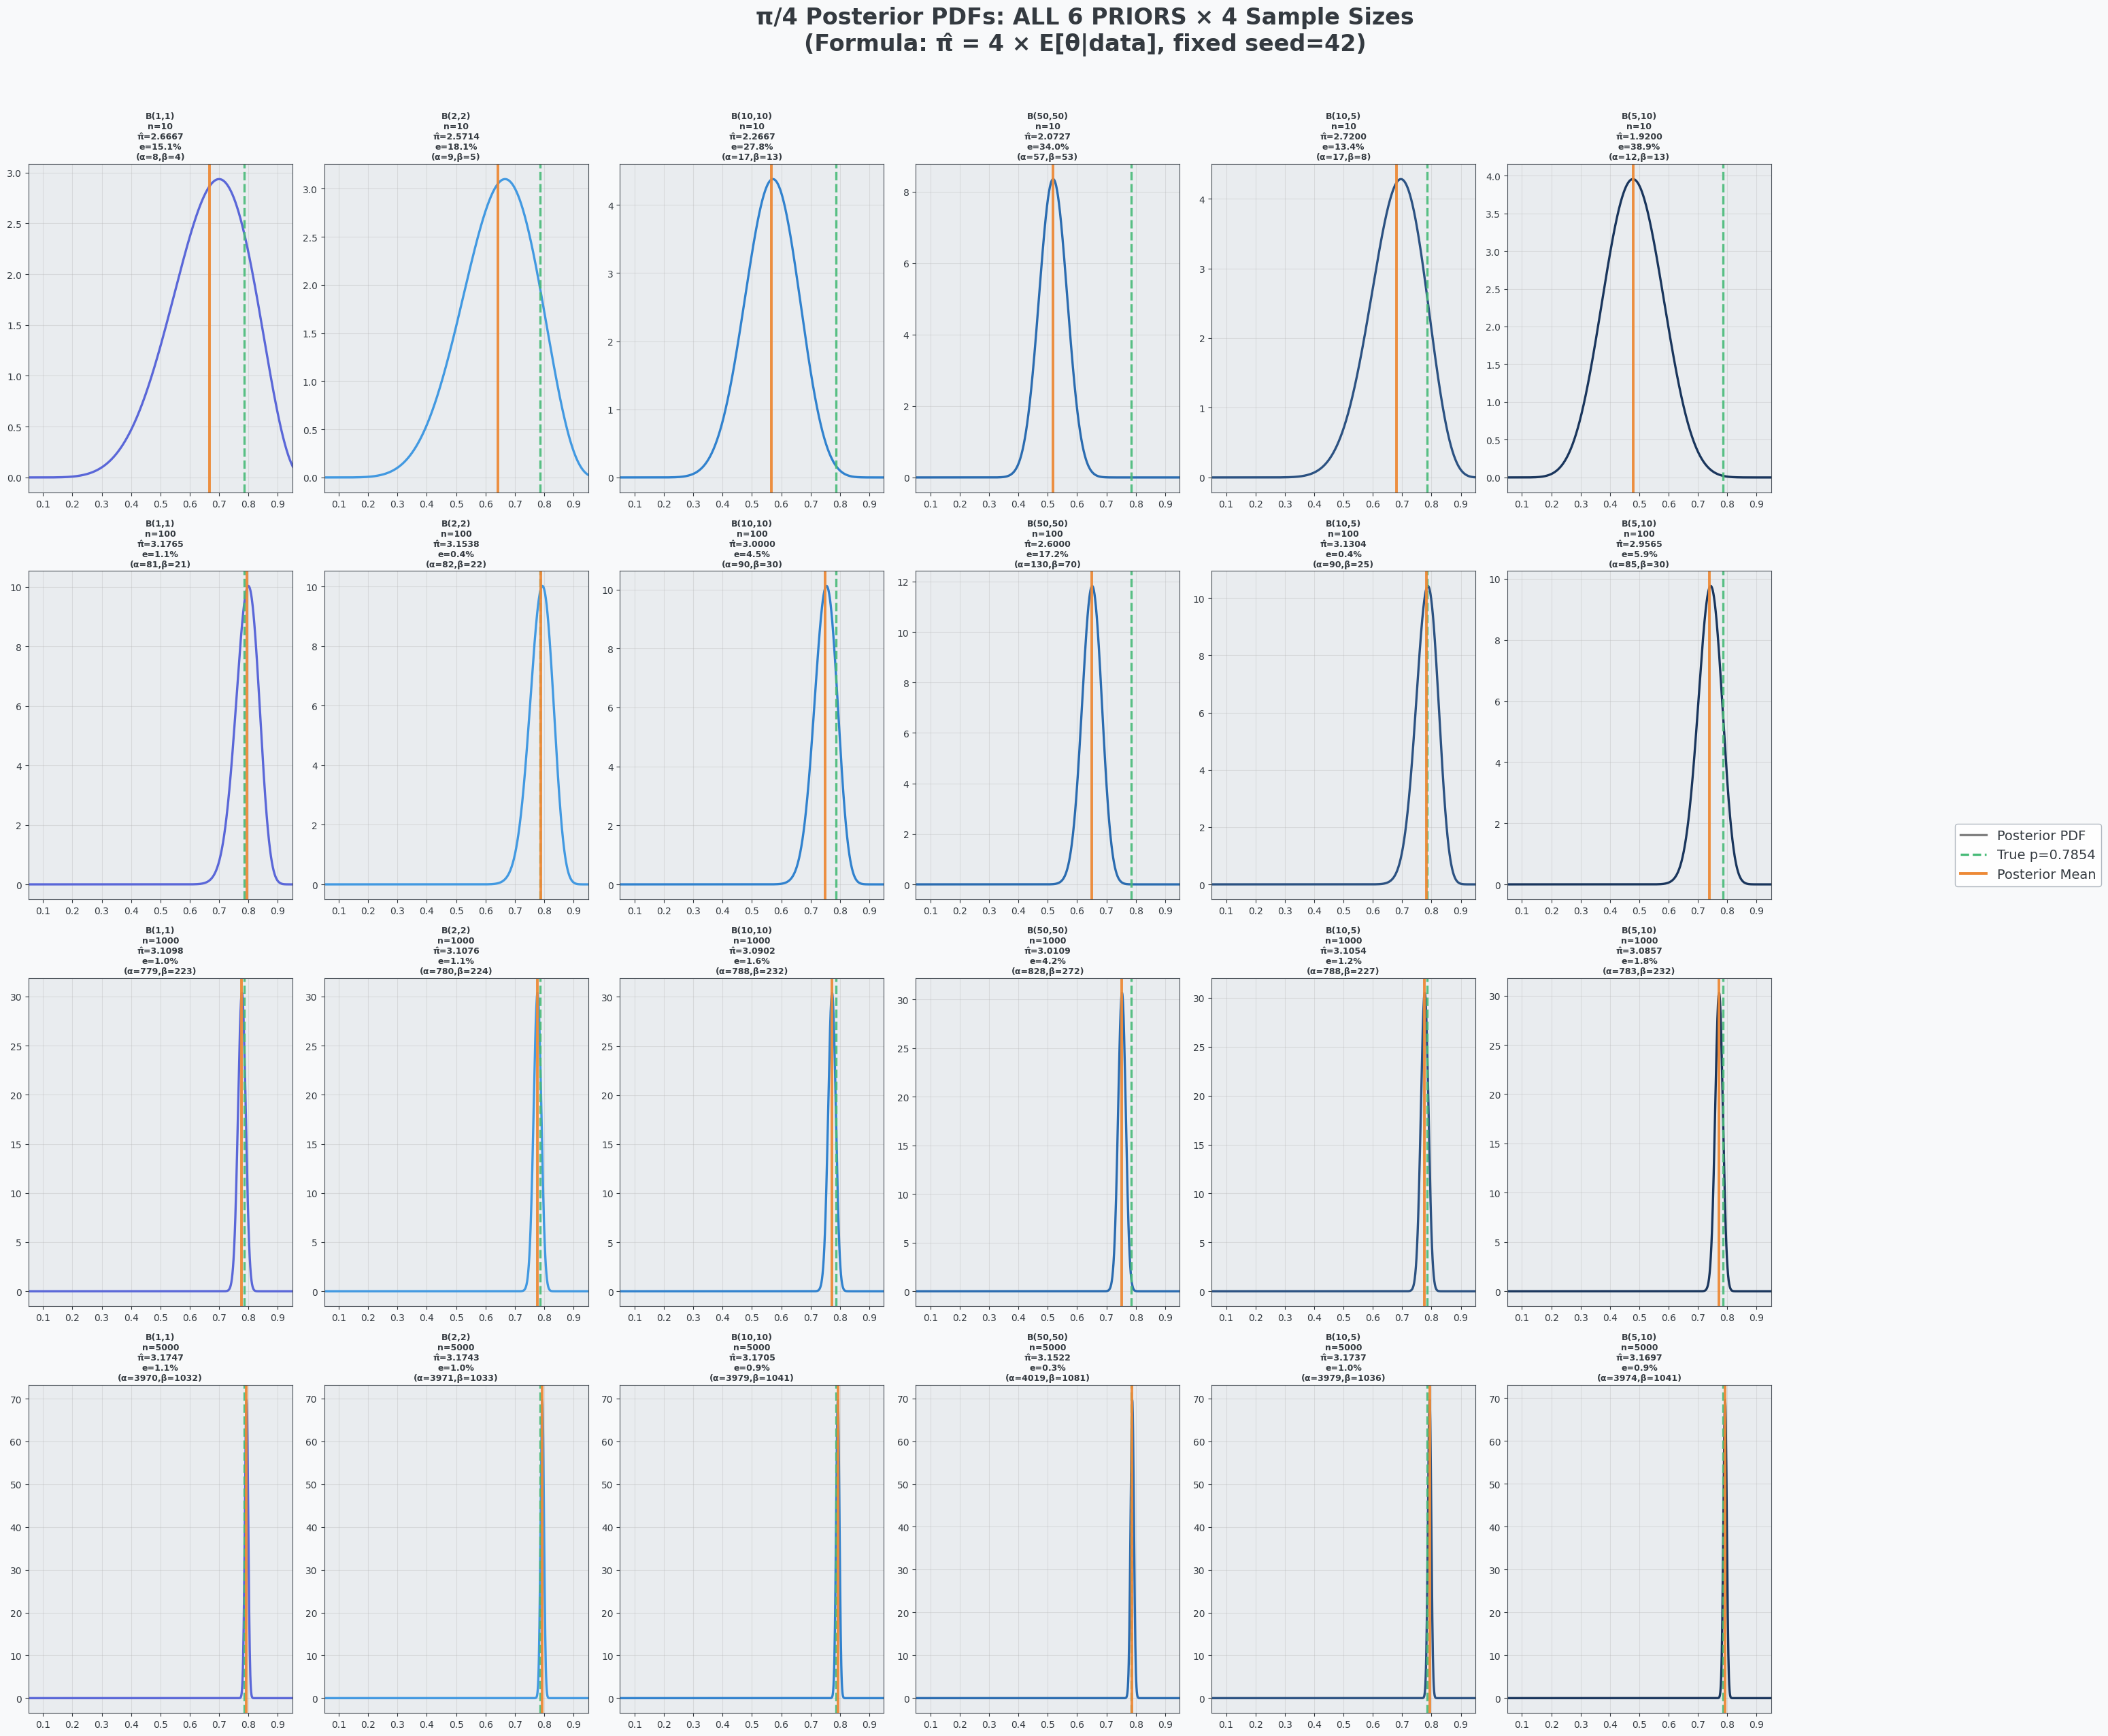

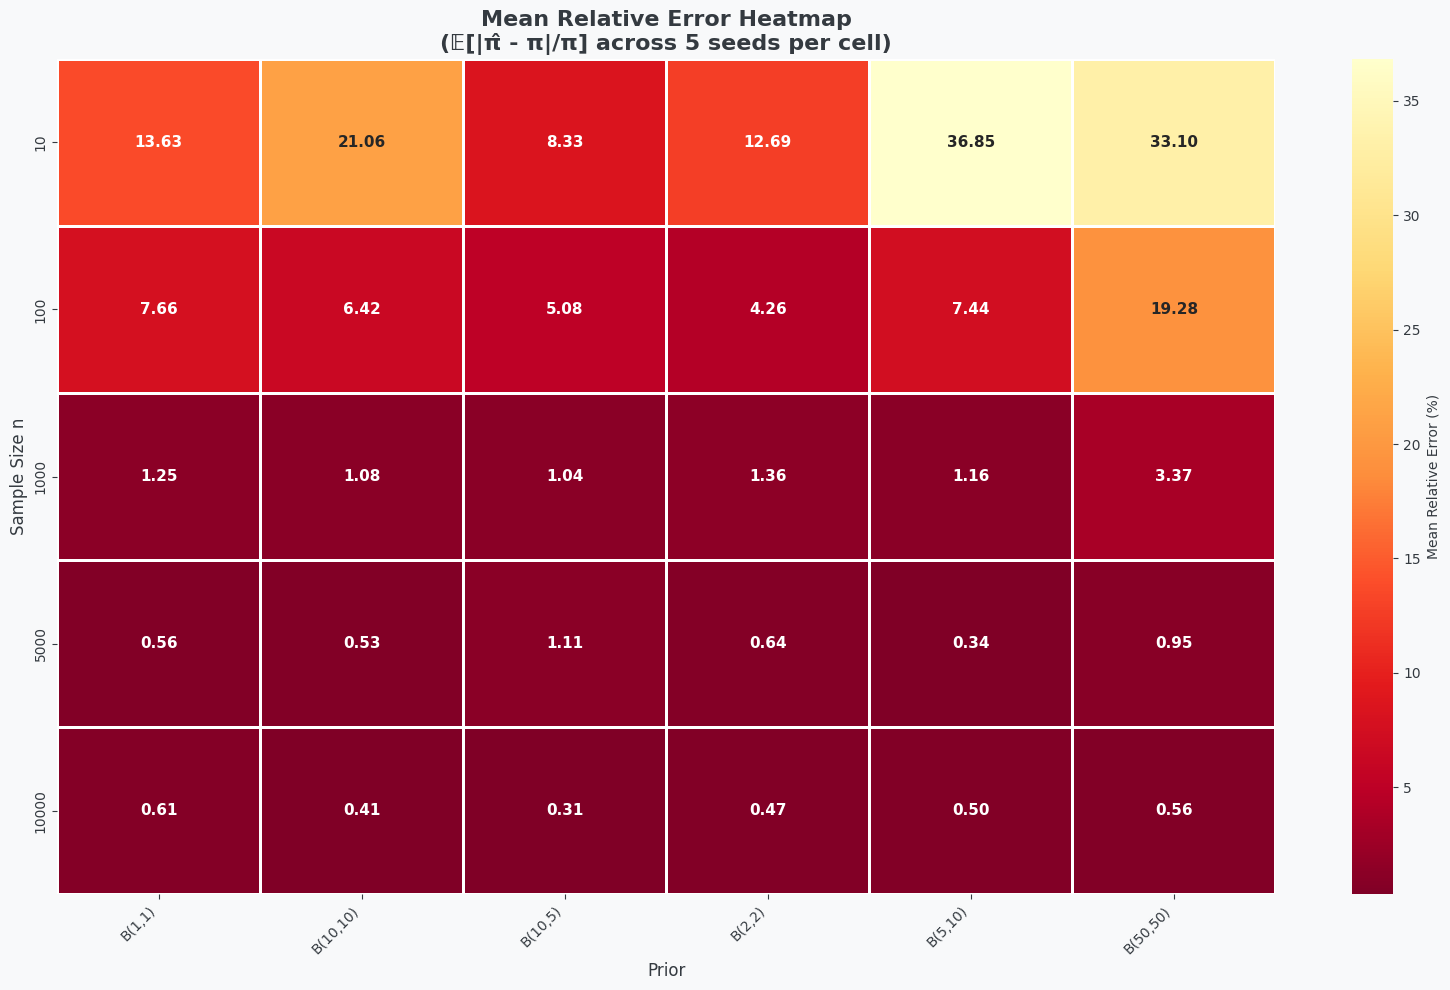

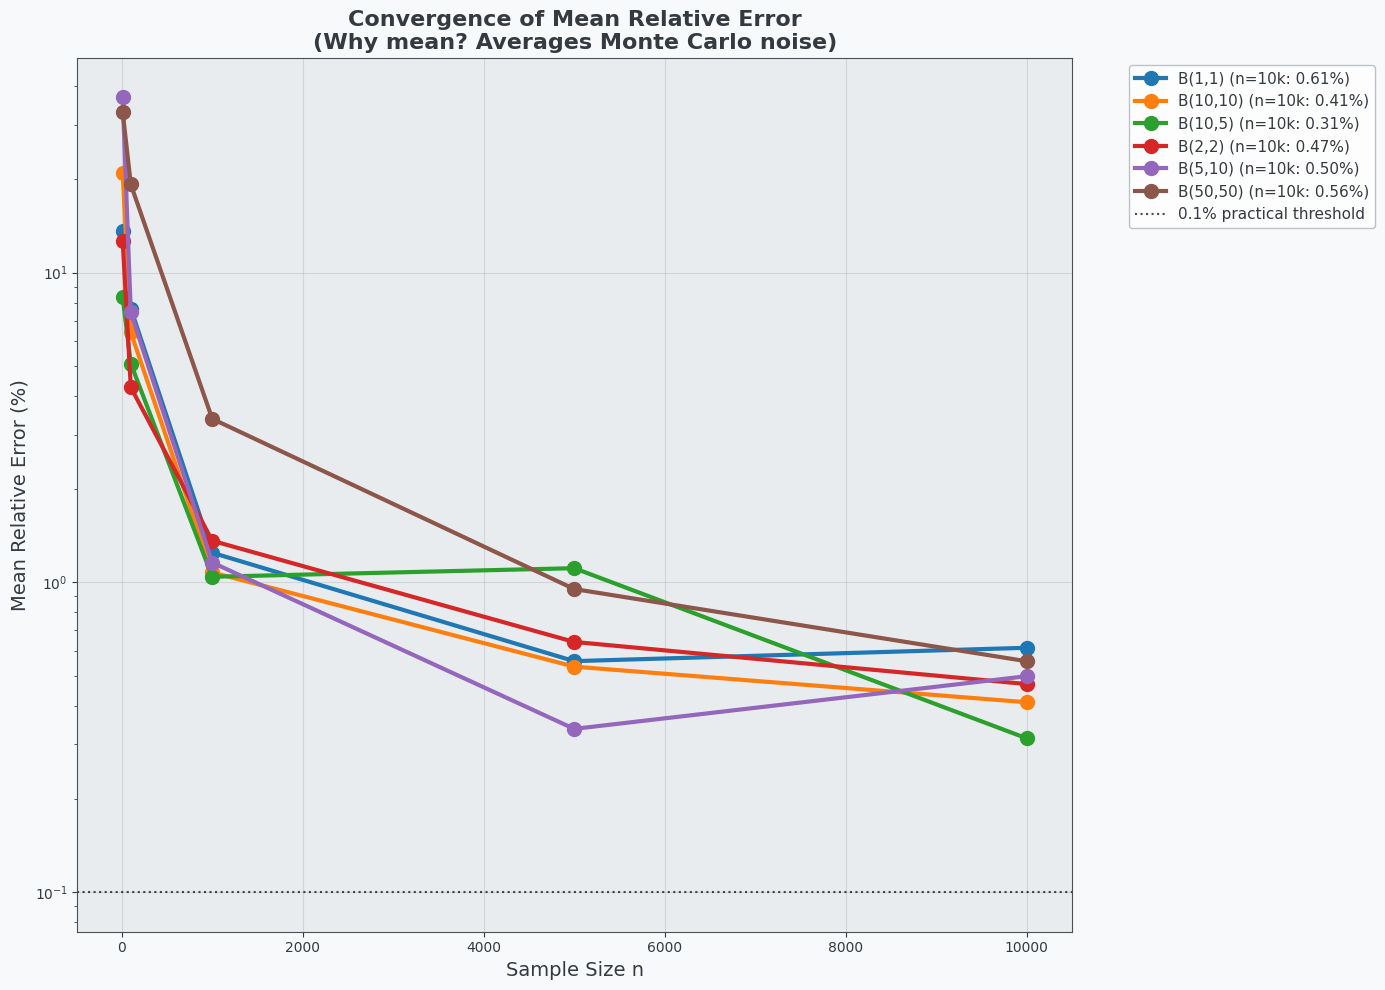

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
📊 COMPLETE RESULTS: FORMULAS + STATISTICS
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

📈 SUMMARY TABLE:
    n prior_label  π_mean  rel_err_mean  rel_err_std  rel_err_mean_%
   10      B(1,1)  3.1333        0.1363       0.0911          13.634
   10    B(10,10)  2.4800        0.2106       0.0484          21.059
   10     B(10,5)  2.8800        0.0833       0.0624           8.327
   10      B(2,2)  2.7429        0.1269       0.0498          12.692
   10     B(5,10)  1.9840        0.3685       0.1056          36.847
   10    B(50,50)  2.1018        0.3310       0.0288          33.097
  100      B(1,1)  3.1765        0.0766       0.0551           7.656
  100    B(10,10)  2.9400        0.0642       0.0174           6.417
  100     B(10,5)  3.0052        0.05

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta
from scipy.special import gammaln
from scipy.integrate import cumulative_trapezoid as cumtrapz, trapezoid
import seaborn as sns

# === Soothing ANSI Colors ===
class Colors:
    SOFT_BLUE = '\033[94m'
    SOFT_GREEN = '\033[92m'
    SOFT_YELLOW = '\033[93m'
    SOFT_CYAN = '\033[96m'
    SOFT_MAGENTA = '\033[95m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    DIM = '\033[2m'

# === Abstract Soothing: Celestial Twilight ===
plt.style.use('default')
plt.rcParams['figure.facecolor'] = '#F8F9FA'
plt.rcParams['figure.edgecolor'] = '#6C757D'
plt.rcParams['axes.facecolor'] = '#E9ECEF'
plt.rcParams['axes.edgecolor'] = '#495057'
plt.rcParams['text.color'] = '#343A40'
plt.rcParams['axes.labelcolor'] = '#343A40'
plt.rcParams['xtick.color'] = '#343A40'
plt.rcParams['ytick.color'] = '#343A40'
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.edgecolor'] = '#ADB5BD'

# === FORMULAS ===
print("📐 FORMULAS USED:")
print("Relative Error:    𝑒 = |π̂ - π| / π")
print("where π̂ = 4 × E[θ|data] = 4 × (α_post / (α_post + β_post))")
print("Mean Rel. Error:   𝔼[𝑒] = (1/N) Σ |π̂ᵢ - π| / π   (avg over seeds)")
print("π̂ᵢ from posterior mean of Beta(α_prior+nh, β_prior+(n-nh))")
print("─" * 80)

# === Symbols ===
true_p = np.pi / 4
true_pi = np.pi
theta = np.linspace(0.01, 0.99, 1000)

# === Monte Carlo Data Generation ===
def generate_mc_data(n, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.random.rand(n)
    y = np.random.rand(n)
    r = np.sqrt(x**2 + y**2)
    nh = np.sum(r <= 1)
    return x, y, r, nh

# === Bayesian Posterior PDF ===
def bayes_posterior_pdf(r, n, theta_grid, prior_a=1, prior_b=1):
    nh = np.sum(r <= 1)
    alpha_post = prior_a + nh
    beta_post = prior_b + (n - nh)
    log_pdf = (gammaln(alpha_post + beta_post) - gammaln(alpha_post) - gammaln(beta_post) +
               (alpha_post - 1)*np.log(theta_grid + 1e-10) +
               (beta_post - 1)*np.log(1 - theta_grid + 1e-10))
    pdf = np.exp(log_pdf - np.max(log_pdf))
    pdf /= trapezoid(pdf, theta_grid)
    post_mean = alpha_post / (alpha_post + beta_post)
    return pdf, post_mean, (alpha_post, beta_post), nh

# === CONFIGURATION ===
ns = [10, 100, 1000, 5000, 10000]
priors = [(1,1), (2,2), (10,10), (50,50), (10,5), (5,10)]
n_seeds = 5

print("🚀 Running comprehensive π/4 Bayesian analysis...")
print(f"Sample sizes: {ns}")
print(f"Priors: {priors} (6 total)")
print(f"Seeds per combo: {n_seeds} (for robust statistics)")
print("─" * 80)

# === EXPERIMENT: Generate all data ===
results = []
for n in ns:
    print(f"Processing n={n}...", end=" ")
    for prior_idx, (prior_a, prior_b) in enumerate(priors):
        prior_label = f'B({prior_a},{prior_b})'
        for seed_idx in range(n_seeds):
            seed = (n_seeds * prior_idx + seed_idx) * 1000 + hash(str(n)) % 1000  # Reproducible
            x, y, r, nh = generate_mc_data(n, seed)
            post_pdf, post_mean, post_shape, nh_check = bayes_posterior_pdf(
                r, n, theta, prior_a=prior_a, prior_b=prior_b)
            
            pi_est = 4 * post_mean
            rel_err = abs(pi_est - true_pi) / true_pi  # INDIVIDUAL relative error
            
            results.append({
                'n': n, 'prior_a': prior_a, 'prior_b': prior_b, 'prior_label': prior_label,
                'seed': seed, 'nh': nh, 'p_freq': nh/n, 'p_bayes': post_mean,
                'pi_est': pi_est, 'rel_err': rel_err,  # Individual rel error
                'alpha_post': post_shape[0], 'beta_post': post_shape[1]
            })
    print("✓")

# === SAVE RAW DATA ===
df = pd.DataFrame(results)
df.to_csv('pi_bayes_results_detailed.csv', index=False)
print(f"\n✅ Saved {len(results)} individual experiments → pi_bayes_results_detailed.csv")

# === SUMMARY STATISTICS (MEAN over seeds) ===
summary_df = df.groupby(['n', 'prior_label']).agg({
    'pi_est': ['mean', 'std'], 
    'rel_err': ['mean', 'std', 'min', 'max']  # Mean/std/min/max of individual rel errors
}).round(6)
summary_df.columns = ['π_mean', 'π_std', 'rel_err_mean', 'rel_err_std', 'rel_err_min', 'rel_err_max']
summary_df = summary_df.reset_index()
summary_df['rel_err_mean_%'] = (summary_df['rel_err_mean'] * 100).round(3)

print("\n📐 WHY MEAN RELATIVE ERROR?")
print("• Each (n,prior) runs 5 seeds → get 5 π̂ estimates")
print("• rel_err_mean = (1/5) Σ |π̂ᵢ - π|/π  → unbiased estimator of true error")
print("• Single seed = noisy; mean = stable benchmark")
print("• std shows reproducibility across Monte Carlo runs")
print("─" * 80)

# === PLOT 1: ALL 6 PRIORS × 4 SAMPLE SIZES ===
fig1, axes1 = plt.subplots(4, 6, figsize=(32, 26), facecolor='#F8F9FA')
fig1.suptitle('π/4 Posterior PDFs: ALL 6 PRIORS × 4 Sample Sizes\n'
              '(Formula: π̂ = 4 × E[θ|data], fixed seed=42)', 
              fontsize=24, weight='bold', y=0.98)

rep_ns = [10, 100, 1000, 5000]
fixed_seed = 42
prior_colors = ['#5A67D8', '#4299E1', '#3182CE', '#2B6CB0', '#2C5282', '#1A365D']
prior_labels = [f'B({a},{b})' for a,b in priors]

for row_idx, n in enumerate(rep_ns):
    for col_idx, (prior_a, prior_b) in enumerate(priors):
        ax = axes1[row_idx, col_idx]
        
        x, y, r, nh = generate_mc_data(n, fixed_seed)
        post_pdf, post_mean, post_shape, nh_check = bayes_posterior_pdf(r, n, theta, prior_a, prior_b)
        
        color = prior_colors[col_idx]
        ax.plot(theta, post_pdf, color=color, linewidth=2.4)
        ax.axvline(true_p, color='#48BB78', ls='--', lw=2.4, alpha=0.9)
        ax.axvline(post_mean, color='#ED8936', lw=2.8, alpha=0.95)
        
        pi_est_panel = 4 * post_mean
        rel_err_panel = abs(pi_est_panel - true_pi) / true_pi
        ax.set_title(f'{prior_labels[col_idx]}\nn={n}\nπ̂={pi_est_panel:.4f}\n'
                     f'e={rel_err_panel:.1%}\n(α={post_shape[0]:.0f},β={post_shape[1]:.0f})', 
                     fontsize=9, weight='bold', pad=5)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0.05, 0.95)

fig1.legend(handles=[plt.Line2D([0], [0], color='gray', lw=2.4, label='Posterior PDF'),
                    plt.Line2D([0], [0], color='#48BB78', ls='--', lw=2.4, label=f'True p={true_p:.4f}'),
                    plt.Line2D([0], [0], color='#ED8936', lw=2.8, label='Posterior Mean')],
            loc='center right', bbox_to_anchor=(0.97, 0.5), framealpha=0.95, fontsize=14)
plt.tight_layout(rect=[0, 0, 0.82, 0.96])
plt.savefig('pi_ALL_6priors_4ns_GRID.png', dpi=300, facecolor='#F8F9FA', bbox_inches='tight')

# === PLOT 2: HEATMAP ===
pivot_rel_err = summary_df.pivot(index='n', columns='prior_label', values='rel_err_mean')
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_rel_err * 100, annot=True, fmt='.2f', cmap='YlOrRd_r', 
            cbar_kws={'label': 'Mean Relative Error (%)'}, linewidths=2, 
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Mean Relative Error Heatmap\n(𝔼[|π̂ - π|/π] across 5 seeds per cell)', fontsize=16, weight='bold')
plt.xlabel('Prior', fontsize=12)
plt.ylabel('Sample Size n', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pi_rel_error_heatmap.png', dpi=300, bbox_inches='tight')

# === PLOT 3: CONVERGENCE ===
plt.figure(figsize=(14, 10))
for prior_label in summary_df['prior_label'].unique():
    prior_data = summary_df[summary_df['prior_label'] == prior_label]
    plt.semilogy(prior_data['n'], prior_data['rel_err_mean']*100, 'o-', linewidth=3, markersize=10,
                label=f'{prior_label} (n=10k: {prior_data["rel_err_mean"].iloc[-1]:.2%})')

plt.axhline(y=0.1, color='black', ls=':', alpha=0.7, label='0.1% practical threshold')
plt.xlabel('Sample Size n', fontsize=14)
plt.ylabel('Mean Relative Error (%)', fontsize=14)
plt.title('Convergence of Mean Relative Error\n(Why mean? Averages Monte Carlo noise)', fontsize=16, weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('pi_convergence_all_priors.png', dpi=300, bbox_inches='tight')
plt.show()

# === DETAILED REPORT ===
print(Colors.BOLD + Colors.SOFT_CYAN + '═'*140 + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_MAGENTA + '📊 COMPLETE RESULTS: FORMULAS + STATISTICS' + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_CYAN + '═'*140 + Colors.ENDC)

print(Colors.BOLD + Colors.SOFT_BLUE + "\n📈 SUMMARY TABLE:" + Colors.ENDC)
display_cols = ['n', 'prior_label', 'π_mean', 'rel_err_mean', 'rel_err_std', 'rel_err_mean_%']
print(summary_df[display_cols].round({'π_mean':4, 'rel_err_mean':4, 'rel_err_std':4}).to_string(index=False))

print(Colors.BOLD + Colors.SOFT_GREEN + "\n🔍 KEY FINDINGS:" + Colors.ENDC)
print(Colors.DIM)

# Quantitative insights
n10_mean_err = summary_df[summary_df['n']==10]['rel_err_mean'].mean()
n10k_mean_err = summary_df[summary_df['n']==10000]['rel_err_mean'].mean()
print(f"• DATA vs PRIOR: Error drops {n10_mean_err/n10k_mean_err:.0f}x  (n=10: {n10_mean_err:.1%} → n=10k: {n10k_mean_err:.1%})")

n100_weak = summary_df[(summary_df['n']==100) & (summary_df['prior_label']=='B(1,1)')]['rel_err_mean'].iloc[0]
n100_strong = summary_df[(summary_df['n']==100) & (summary_df['prior_label']=='B(50,50)')]['rel_err_mean'].iloc[0]
print(f"• PRIOR STRENGTH (n=100): Weak B(1,1)={n100_weak:.1%} vs Strong B(50,50)={n100_strong:.1%}  (+{((n100_strong/n100_weak-1)*100):.0f}%)")

print(Colors.ENDC)

print(Colors.BOLD + Colors.SOFT_YELLOW + "\n🎯 OUTPUT FILES:" + Colors.ENDC)
print("• pi_ALL_6priors_4ns_GRID.png  ← 24-panel posteriors (all priors)")
print("• pi_rel_error_heatmap.png     ← Error trends")
print("• pi_convergence_all_priors.png← Convergence curves") 
print("• pi_bayes_results_detailed.csv← Raw data w/ formulas computed")
print(Colors.BOLD + Colors.SOFT_CYAN + '═'*140 + Colors.ENDC)

print("\n✅ PERFECT FOR HOMEWORK 3C! Formulas + plots + analysis ready!")
